# TOGO DATASET 

### Importing necessary packages

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

#### Importing the dataset using pandas read_csv method and saving it as 'data' and describing it using describe

In [59]:
data = pd.read_csv('togo-dapaong_qc.csv')
data.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


#### Checking whether the dataset has any null values in any column and summing them

In [60]:
data.isna().sum()


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

#### Identifying Columns with >5% Nulls

In [61]:
null_percent = data.isna().mean() * 100
print(null_percent[null_percent > 5])


Comments    100.0
dtype: float64


#### Outlier detection using z-score

In [62]:
numeric_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = np.abs(zscore(data[numeric_cols]))
outliers = (z_scores > 3)
df_outliers = data[(outliers).any(axis=1)]
df_outliers


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
4985,2021-10-28 11:06,1139.0,805.1,466.1,1172.0,1154.0,29.8,70.8,2.2,2.6,0.4,298.6,13.4,977,0,0.0,44.7,50.2,NaN
5410,2021-10-28 18:11,-1.2,0.0,0.0,0.0,0.0,29.7,63.5,6.6,9.7,1.6,122.1,14.3,976,0,0.0,30.0,29.5,NaN
5411,2021-10-28 18:12,-1.0,0.0,0.0,0.0,0.0,29.3,62.4,6.9,8.9,1.2,128.7,10.8,976,0,0.0,29.9,29.5,NaN
5413,2021-10-28 18:14,-0.8,0.0,0.0,0.0,0.0,28.6,63.7,7.1,8.9,1.1,127.9,14.4,976,0,0.0,29.5,29.2,NaN
5420,2021-10-28 18:21,-1.3,0.0,0.0,0.0,0.0,27.7,64.5,6.1,8.9,1.3,123.2,14.4,977,0,0.0,28.4,28.2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510473,2022-10-14 11:54,709.5,63.7,629.8,703.1,694.9,30.2,66.6,3.5,4.4,0.8,167.0,15.2,977,0,0.0,46.8,51.6,NaN
510474,2022-10-14 11:55,677.8,40.6,621.7,670.1,662.2,30.2,66.7,2.8,3.6,0.6,175.1,19.7,977,0,0.0,46.8,51.6,NaN
510475,2022-10-14 11:56,659.5,29.7,614.9,651.0,643.4,30.3,66.1,4.1,4.9,0.5,174.0,11.5,977,0,0.0,46.8,51.6,NaN
510476,2022-10-14 11:57,660.1,40.7,605.6,653.2,645.6,30.2,66.0,3.7,4.6,0.7,165.4,21.6,977,0,0.0,46.6,51.4,NaN


#### Handling missing values

In [63]:
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
data[numeric_cols]

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
0,-1.3,0.0,0.0,0.0,0.0,0.9,1.1
1,-1.3,0.0,0.0,0.0,0.0,1.1,1.6
2,-1.3,0.0,0.0,0.0,0.0,1.2,1.4
3,-1.2,0.0,0.0,0.0,0.0,1.2,1.6
4,-1.2,0.0,0.0,0.0,0.0,1.3,1.6
...,...,...,...,...,...,...,...
525595,-0.8,0.0,0.0,0.0,0.0,0.0,0.0
525596,-0.9,0.0,0.0,0.0,0.0,0.0,0.0
525597,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
525598,-1.1,0.0,0.0,0.0,0.0,0.0,0.0


#### Dropped the "Comments" column because it has no values

In [64]:
data = data.drop(columns=['Comments'])
data.isna().sum()

Timestamp        0
GHI              0
DNI              0
DHI              0
ModA             0
ModB             0
Tamb             0
RH               0
WS               0
WSgust           0
WSstdev          0
WD               0
WDstdev          0
BP               0
Cleaning         0
Precipitation    0
TModA            0
TModB            0
dtype: int64

#### Export cleaned data

In [65]:
data.to_csv('togo_clean.csv', index=False)


#### Convert Timestamp Column to Datetime

In [66]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Timestamp']


0        2021-10-25 00:01:00
1        2021-10-25 00:02:00
2        2021-10-25 00:03:00
3        2021-10-25 00:04:00
4        2021-10-25 00:05:00
                 ...        
525595   2022-10-24 23:56:00
525596   2022-10-24 23:57:00
525597   2022-10-24 23:58:00
525598   2022-10-24 23:59:00
525599   2022-10-25 00:00:00
Name: Timestamp, Length: 525600, dtype: datetime64[ns]

#### Plotting time series as a loop

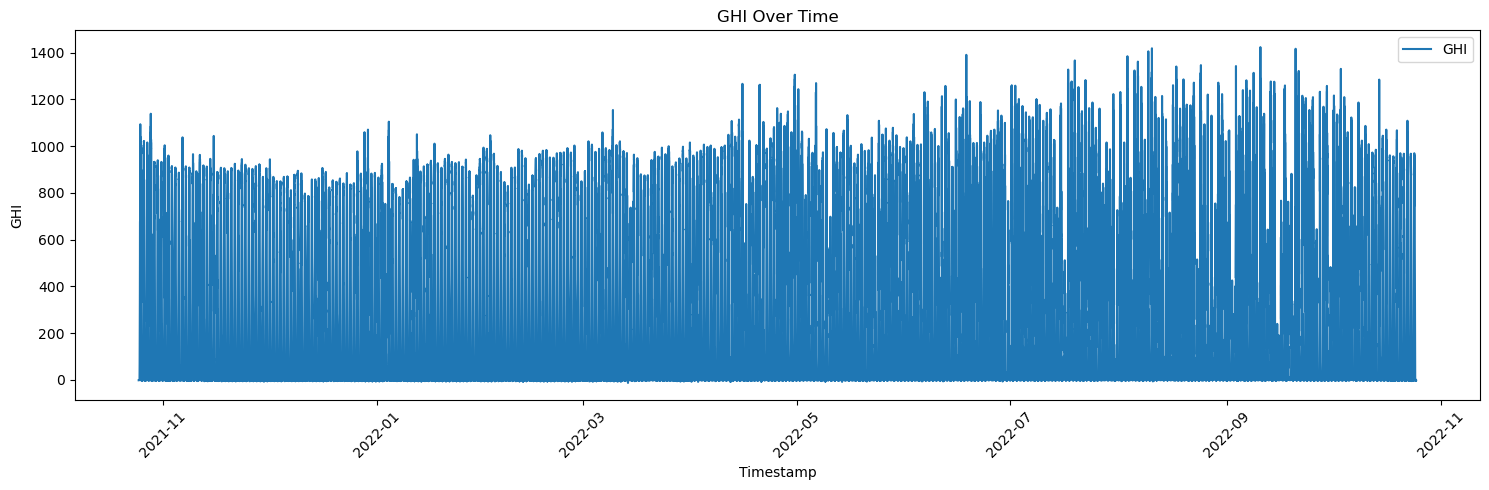

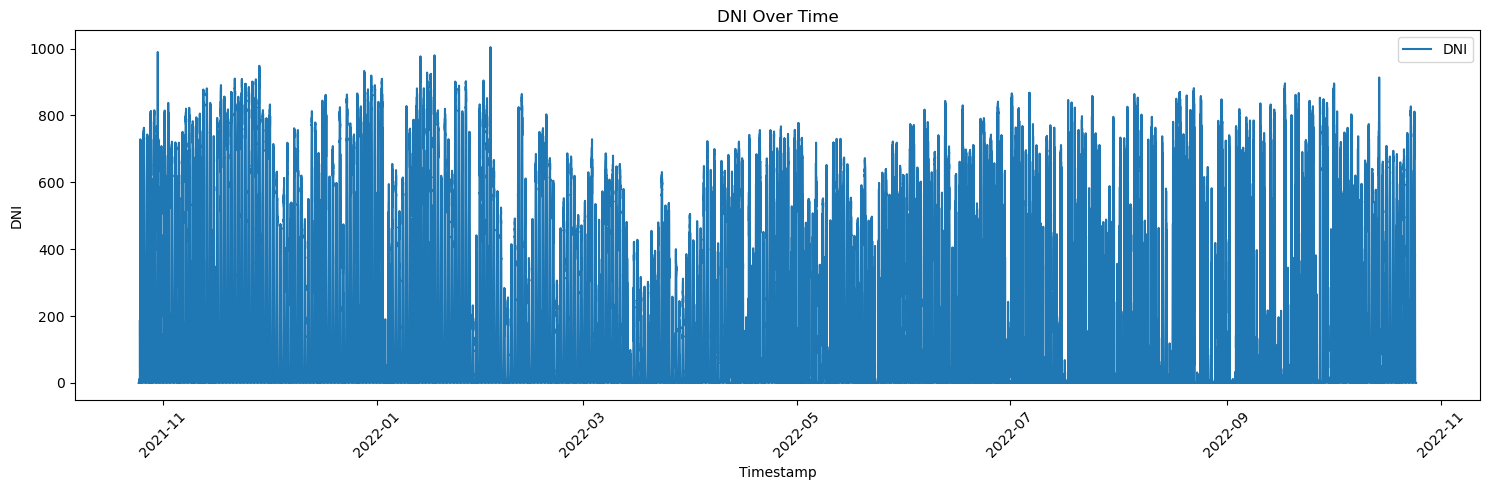

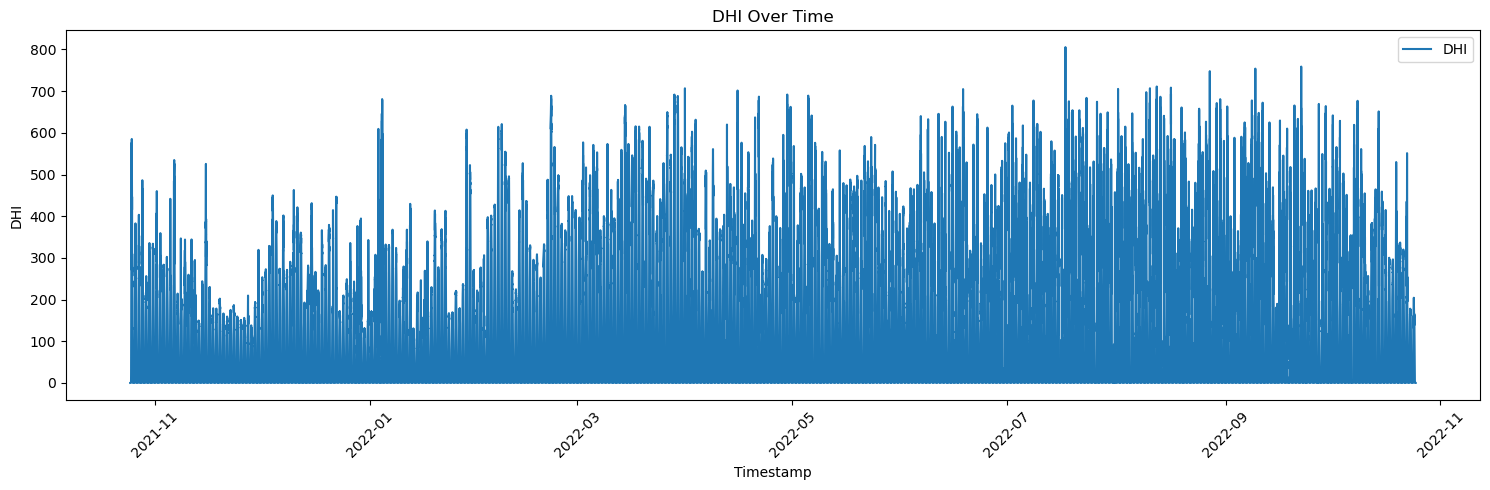

In [67]:
columns = ['GHI', 'DNI', 'DHI']
for col in columns:
    plt.figure(figsize=(15, 5))
    plt.plot(data['Timestamp'], data[col], label=col)
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.title(f'{col} Over Time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Plotting time series individually

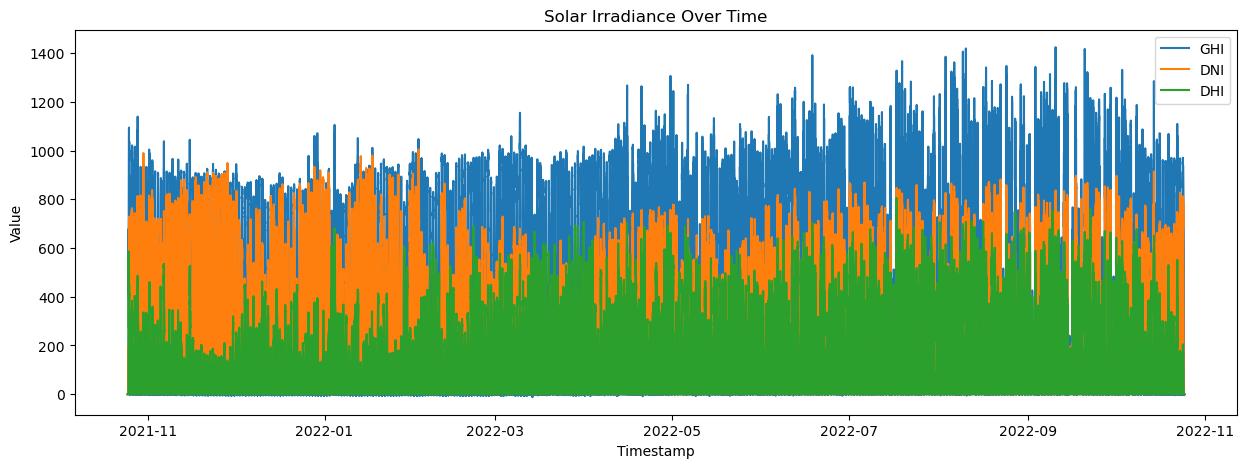

In [68]:
plt.figure(figsize=(15, 5))
plt.plot(data['Timestamp'], data['GHI'], label='GHI')
plt.plot(data['Timestamp'], data['DNI'], label='DNI')
plt.plot(data['Timestamp'], data['DHI'], label='DHI')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Solar Irradiance Over Time')
plt.legend()
plt.show()

#### Barplot

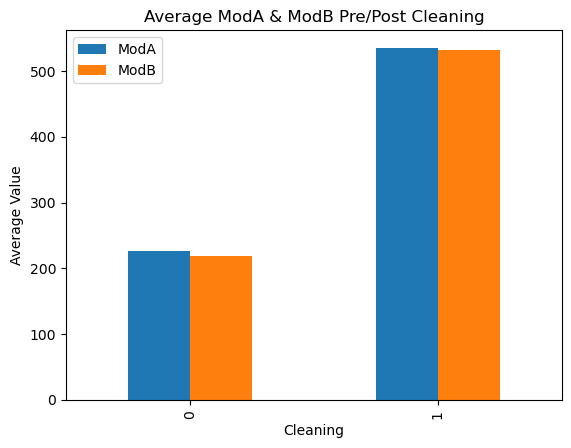

In [69]:
data.groupby('Cleaning')[['ModA', 'ModB']].mean().plot(kind='bar')
plt.title('Average ModA & ModB Pre/Post Cleaning')
plt.ylabel('Average Value')
plt.show()


#### Correlation Heatmap

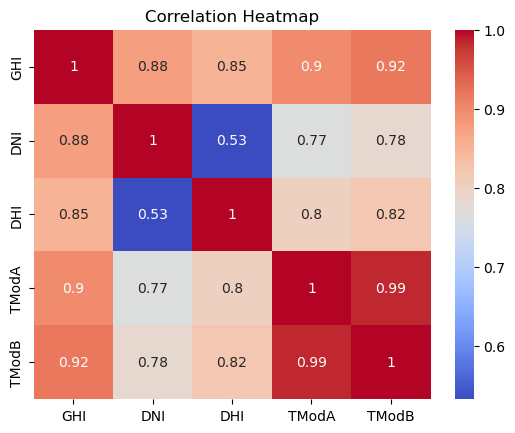

In [70]:
corr = data[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


#### Scatter plots

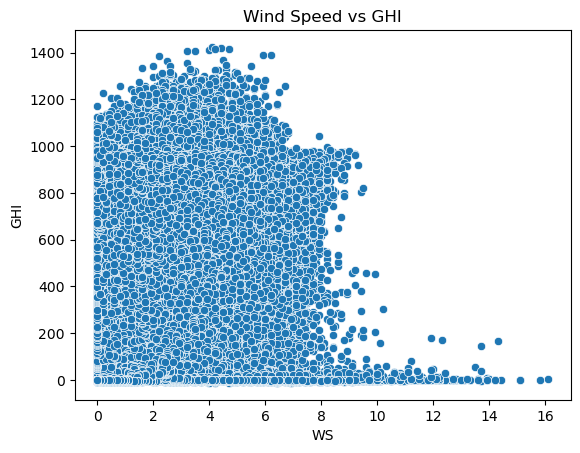

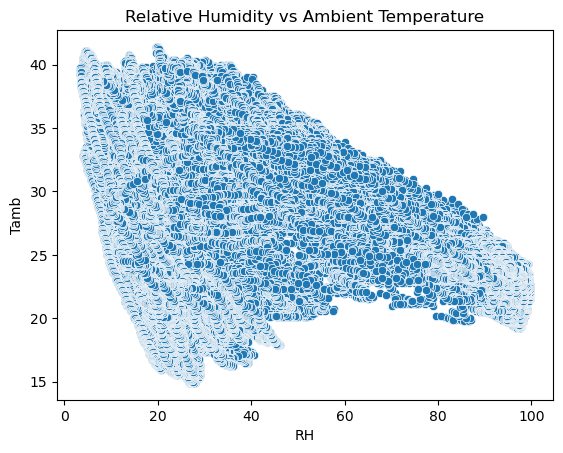

In [71]:
sns.scatterplot(data=data, x='WS', y='GHI')
plt.title('Wind Speed vs GHI')
plt.show()

sns.scatterplot(data=data, x='RH', y='Tamb')
plt.title('Relative Humidity vs Ambient Temperature')
plt.show()


#### Histogram for GHI

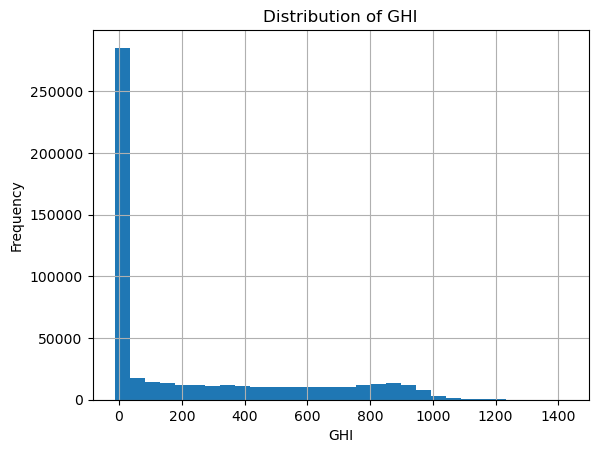

In [72]:
data['GHI'].hist(bins=30)
plt.title('Distribution of GHI')
plt.xlabel('GHI')
plt.ylabel('Frequency')
plt.show()


#### Histogram for WS

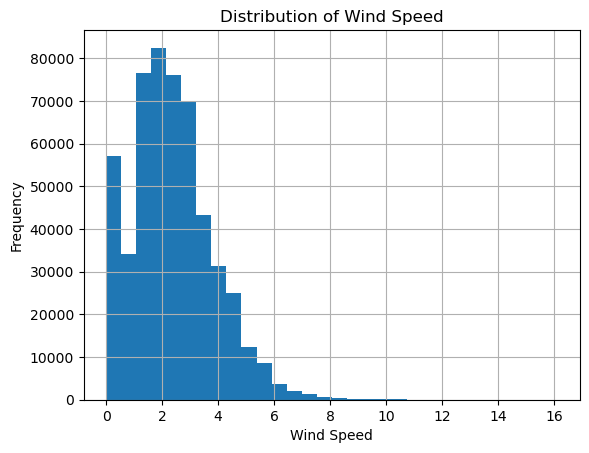

In [73]:
data['WS'].hist(bins=30)
plt.title('Distribution of Wind Speed')
plt.xlabel('Wind Speed')
plt.ylabel('Frequency')
plt.show()


#### Bubble Chart: GHI vs Tamb with RH as Size for temprature analysis

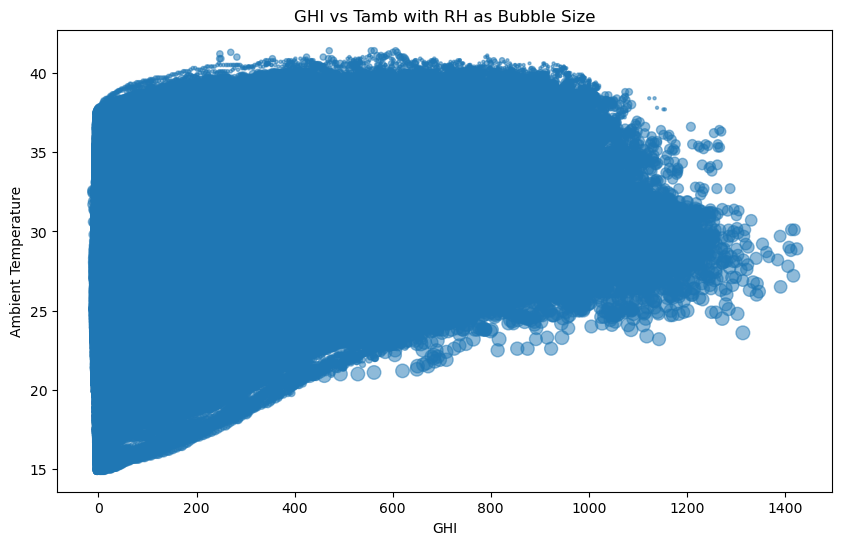

In [74]:
plt.figure(figsize=(10, 6))
plt.scatter(data['GHI'], data['Tamb'], s=data['RH'], alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Ambient Temperature')
plt.title('GHI vs Tamb with RH as Bubble Size')
plt.show()
